# Module 2 — Brief 1 — Audit et documentation du dataset FastIA

Ce notebook couvre les étapes de l'audit :

- Audit quantitatif (distributions, longueurs, doublons, valeurs manquantes)
- Audit qualitatif (échantillonnage et relecture)
- Repérage des données potentiellement sensibles
- Synthèse alimentant la datasheet et le diagnostic

Les cellules marquées `### A COMPLÉTER ###` contiennent du code partiel à terminer.
Les cellules sans marqueur sont fournies et peuvent être exécutées directement.

Prérequis : le fichier `data/raw/dataset_fastia_module1.jsonl` est en place.

---
## 0. Imports et configuration

In [1]:
import json
import re
import hashlib
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

print("Imports OK")

Imports OK


In [19]:
DATASET_PATH = Path("data/raw/dataset_fastia_module1.jsonl")

CATEGORIES_ATTENDUES = [
    "Support technique",
    "Demande commerciale",
    "Demande de transformation",
    "Réclamation",
    "Information générale",
]

PRIORITES_ATTENDUES = ["haute", "normale"]

---
## 1. Chargement et aplatissement

Le dataset est au format JSON Lines avec un champ `output` imbriqué. On l'aplatit pour pouvoir l'analyser en DataFrame.

In [20]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append({
                "input": obj.get("input", ""),
                "categorie": obj.get("output", {}).get("categorie", ""),
                "priorite": obj.get("output", {}).get("priorite", ""),
                "reponse_suggeree": obj.get("output", {}).get("reponse_suggeree", ""),
            })
    return pd.DataFrame(rows)


df = load_jsonl(DATASET_PATH)
print(f"Nombre d'exemples : {len(df)}")
df.head()

Nombre d'exemples : 96


,input,categorie,priorite,reponse_suggeree
0,"Bonjour, notre application de gestion RH plante depuis ce matin, impossible de se connecter. Toute l'équipe est bloq...",Support technique,haute,Nous prenons en charge votre incident en priorité. Notre équipe technique est mobilisée et reviendra vers vous dans ...
1,"Le serveur de production est tombé il y a 30 minutes, nos clients ne peuvent plus accéder au service.",Support technique,haute,Incident critique enregistré. Nous escaladons immédiatement auprès de notre équipe infrastructure. Un point de situa...
2,"Depuis la dernière mise à jour, les exports PDF ne fonctionnent plus correctement, les tableaux sont tronqués.",Support technique,haute,"Nous avons identifié un problème lié à la dernière mise à jour. Un correctif est en cours de déploiement, vous serez..."
3,"Notre pipeline de données s'est arrêté cette nuit, les rapports du matin sont vides.",Support technique,haute,Incident enregistré sur votre pipeline de données. Notre équipe data est alertée et analyse les logs. Un retour sous...
4,"URGENT : faille de sécurité détectée sur notre API exposée, des données clients pourraient être compromises.",Support technique,haute,Nous traitons cet incident de sécurité en priorité absolue. L'API sera isolée dans les plus brefs délais. Notre équi...


---
## 2. Audit quantitatif

Produire des distributions claires. Chaque graphique doit pouvoir être inclus tel quel dans la datasheet.

### 2.1 Distribution des catégories

categorie
Support technique            22
Information générale         22
Demande commerciale          18
Demande de transformation    17
Réclamation                  17
Name: count, dtype: int64


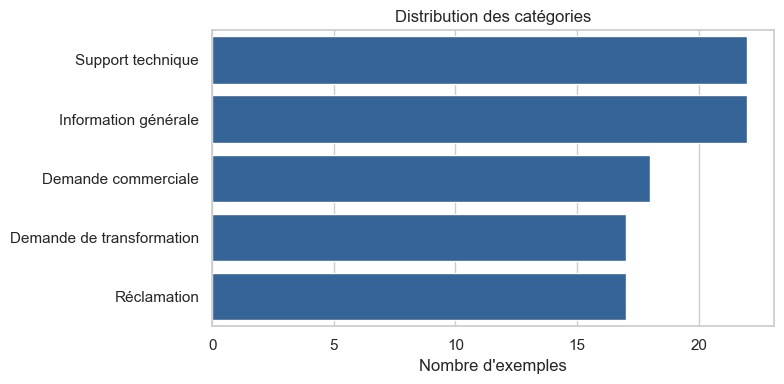

In [27]:
cat_counts = df["categorie"].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, color="#2563a8")
ax.set_xlabel("Nombre d'exemples")
ax.set_ylabel("")
ax.set_title("Distribution des catégories")
plt.tight_layout()

### 2.2 Distribution des priorités (globale et par catégorie)

priorite
normale    68
haute      28
Name: count, dtype: int64
priorite                   haute  normale
categorie                                
Demande commerciale            7       11
Demande de transformation      7       10
Information générale           0       22
Réclamation                    7       10
Support technique              7       15


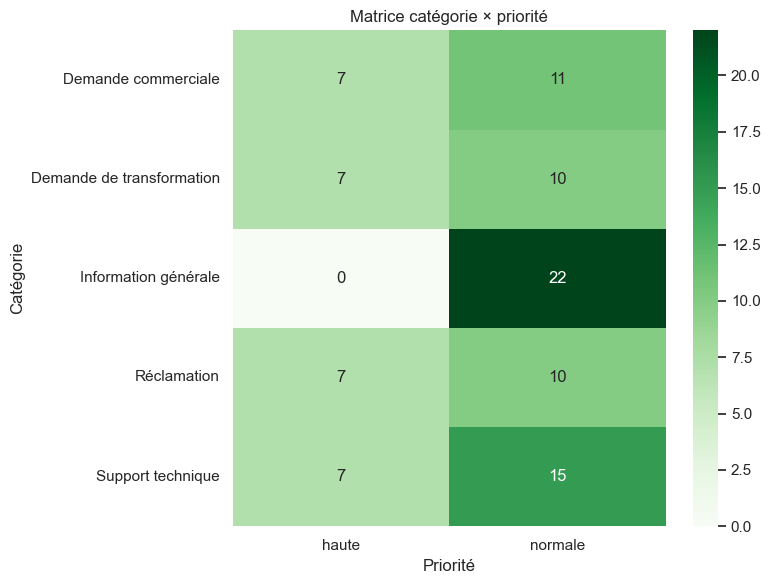

In [ ]:
### A COMPLÉTER ###
# Objectif : produire deux vues
#
# 1. Distribution globale des priorités (haute vs normale)
prio_counts = df["priorite"].value_counts()
print(prio_counts)
# 2. Matrice catégorie × priorité (crosstab + heatmap)
crosstab = pd.crosstab(df["categorie"], df["priorite"])
print(crosstab)
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Greens")
plt.title("Matrice catégorie × priorité")
plt.xlabel("Priorité")
plt.ylabel("Catégorie")
plt.tight_layout()
#
# Question à consigner : certaines combinaisons sont-elles absentes ou sous-représentées ?

# Une combinaison absente : 
#   La catégorie "Information générale" + priorité "haute" a un score de 0
# Combinaison sous-représentée : 
#   Les catégories "Demande commerciale", "Demande de transformation", "Support technique" et "Réclamation" sont à égalité en priorité haute (7)

# 1. Distribution globale
#   La majorité sont de priorité "normale", 68 exemples contre 28 de priorité "haute".
#   Les catégories "Support technique" et "Information générale" sont les plus fréquentes, avec respectivement 22 exemples.

# 2. Crosstab + heatmap
#   Les catégories ne sont pas représentées de manière équilibrée entre les priorités. 
#   Par exemple, la catégorie "Information générale" n'a aucune instance de priorité "haute", 
# 

### 2.3 Distribution des longueurs

       len_input_chars  len_input_words  len_reponse_chars
count             96.0             96.0               96.0
mean             100.7             15.8              158.0
std               24.5              4.1               16.1
min               44.0              7.0              128.0
25%               84.8             12.8              147.0
50%               99.0             16.0              155.0
75%              117.0             18.0              167.8
max              172.0             31.0              200.0


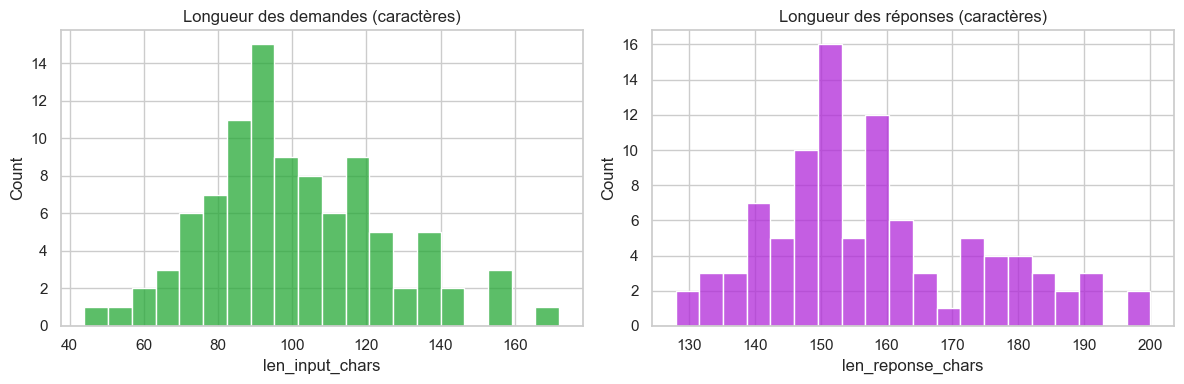

In [28]:
df["len_input_chars"] = df["input"].str.len()
df["len_reponse_chars"] = df["reponse_suggeree"].str.len()
df["len_input_words"] = df["input"].str.split().map(len)

print(df[["len_input_chars", "len_input_words", "len_reponse_chars"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["len_input_chars"], bins=20, ax=axes[0], color="#25a836")
axes[0].set_title("Longueur des demandes (caractères)")
sns.histplot(df["len_reponse_chars"], bins=20, ax=axes[1], color="#b028d9")
axes[1].set_title("Longueur des réponses (caractères)")
plt.tight_layout()

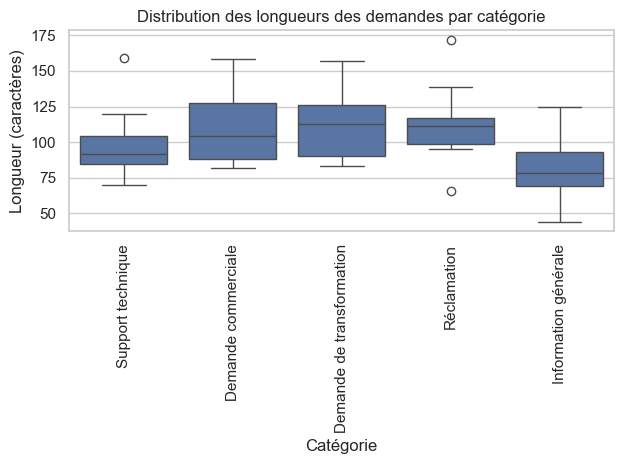

In [ ]:
### A COMPLÉTER ###
# Objectif : comparer les longueurs par catégorie
#
# 1. Un boxplot de len_input_chars par categorie
sns.boxplot(data=df, x="categorie", y="len_input_chars")
plt.title("Distribution des longueurs des demandes par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Longueur (caractères)")
plt.xticks(rotation=90)
plt.tight_layout()


# 2. Repérer les catégories avec une dispersion anormale
#
# Question à consigner : y a-t-il une catégorie où la longueur prédit mieux que le contenu ?
# (C'est un indice de biais que le modèle pourrait apprendre.)
#   La catégorie "Information générale" est celle qui présente le plus fort risque de biais lié à la longueur
#   Elle possède la médiane la plus basse (environ 75-80 caractères) et sa boîte (l'écart interquartile) ne chevauche quasiment pas celles des autres catégories
#   Conséquence : le modèle risque de prédire "Information générale" en se basant principalement sur la longueur de la demande plutôt que sur son contenu.


### 2.4 Doublons

In [30]:
def normalize_for_hash(s: str) -> str:
    return re.sub(r"\s+", " ", s.strip().lower())


df["input_hash"] = df["input"].map(lambda s: hashlib.md5(normalize_for_hash(s).encode()).hexdigest())

exact_dups = df.duplicated(subset=["input"], keep=False).sum()
normalized_dups = df.duplicated(subset=["input_hash"], keep=False).sum()

print(f"Doublons exacts sur input   : {exact_dups}")
print(f"Doublons après normalisation: {normalized_dups}")

Doublons exacts sur input   : 0
Doublons après normalisation: 0


### 2.5 Valeurs manquantes et hors schéma

In [34]:
### A COMPLÉTER ###
# Objectif : vérifier le respect du schéma
#
# 1. Compter les lignes avec input vide ou très court (< 10 caractères)
empty_or_small_input_counts = (df["input"].str.len() < 10).sum()
print(f"Lignes avec input vide ou très court : {empty_or_small_input_counts}")

# 2. Compter les lignes avec une categorie hors de CATEGORIES_ATTENDUES
cat_invalid_counts = (~df["categorie"].isin(CATEGORIES_ATTENDUES)).sum()
print(f"Lignes avec categorie hors des CATEGORIES_ATTENDUES : {cat_invalid_counts}")

# 3. Compter les lignes avec une priorite hors de PRIORITES_ATTENDUES
prio_invalid_counts = (~df["priorite"].isin(PRIORITES_ATTENDUES)).sum()
print(f"Lignes avec priorite hors des PRIORITES_ATTENDUES : {prio_invalid_counts}")

# 4. Compter les lignes avec reponse_suggeree vide
empty_response_counts = (df["reponse_suggeree"].str.strip() == "").sum()
print(f"Lignes avec reponse_suggeree vide : {empty_response_counts}")
#
# Consigner les résultats dans un tableau récapitulatif.
validation_results = {
    "Vérification": [
        "Input vide ou très court (< 10 caractères)",
        "Categorie hors de CATEGORIES_ATTENDUES",
        "Priorite hors de PRIORITES_ATTENDUES",
        "Reponse suggeree vide",
    ],
    "Nombre d'exemples invalides": [
        empty_or_small_input_counts,
        cat_invalid_counts,
        prio_invalid_counts,
        empty_response_counts,
    ],
}
validation_df = pd.DataFrame(validation_results)
print(validation_df)


Lignes avec input vide ou très court : 0
Lignes avec categorie hors des CATEGORIES_ATTENDUES : 0
Lignes avec priorite hors des PRIORITES_ATTENDUES : 0
Lignes avec reponse_suggeree vide : 0
                                 Vérification  Nombre d'exemples invalides
0  Input vide ou très court (< 10 caractères)                            0
1      Categorie hors de CATEGORIES_ATTENDUES                            0
2        Priorite hors de PRIORITES_ATTENDUES                            0
3                       Reponse suggeree vide                            0


---
## 3. Audit qualitatif

Tirer 4 exemples par catégorie (seed fixée) et les relire.

In [35]:
echantillon = (
    df.groupby("categorie", group_keys=False)
      .apply(lambda g: g.sample(min(4, len(g)), random_state=42))
      .reset_index(drop=True)
)

for _, row in echantillon.iterrows():
    print(f"[{row.categorie} | {row.priorite}]")
    print(f"  input  : {row.input}")
    print(f"  réponse: {row.reponse_suggeree}")
    print()

[Demande commerciale | haute]
  input  : Bonjour, nous souhaitons obtenir un devis pour l'intégration de votre solution IA dans notre CRM Salesforce.
  réponse: Merci pour votre intérêt. Notre équipe commerciale va vous recontacter dans les 24h pour qualifier votre besoin et établir une proposition adaptée.

[Demande commerciale | haute]
  input  : Nous avons un projet urgent de transformation digitale à démarrer en janvier, pouvez-vous nous proposer une offre rapidement ?
  réponse: Nous prenons en compte l'urgence de votre projet. Un consultant senior vous contacte aujourd'hui pour cadrer le besoin et vous soumettre une proposition sous 48h.

[Demande commerciale | normale]
  input  : Pouvez-vous nous envoyer une plaquette commerciale de vos services pour la présenter à notre direction ?
  réponse: Bien sûr, nous vous envoyons notre plaquette commerciale par retour de message. N'hésitez pas si vous souhaitez un rendez-vous de présentation.

[Demande commerciale | haute]
  input  : No

C:\Users\shtou\AppData\Local\Temp\ipykernel_20036\2311948784.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(4, len(g)), random_state=42))


In [45]:
### A COMPLÉTER ###
# Objectif : noter pour chacun des 20 exemples
#
# Construire un DataFrame de revue avec les colonnes :
#   idx, categorie_ok (bool), priorite_ok (bool), reponse_ok (bool),
#   contient_pii (bool), commentaire (str)
revue_df = pd.DataFrame({
    'idx': echantillon.index,
    'contenu': echantillon.categorie + " | " + echantillon.priorite + "\n" + "input : " + echantillon.input + "\n" + "reponse : "+ echantillon.reponse_suggeree,
    'categorie_ok': True,
    'priorite_ok': True,
    'reponse_ok': True,
    'contient_pii': False,
    'commentaire': "",
})
#
# Sauvegarder le résultat dans docs/revue_qualitative.csv
Path("docs").mkdir(exist_ok=True)
revue_df.to_csv("docs/revue_qualitative.csv", index=False, encoding="utf-8")



---
## 4. Repérage des données potentiellement sensibles

Passe rapide par regex. L'objectif n'est pas d'anonymiser ici (ce sera au Brief 2) mais de **savoir ce qu'on a**.

In [37]:
PII_PATTERNS = {
    "email":     re.compile(r"[\w\.-]+@[\w\.-]+\.\w+"),
    "telephone": re.compile(r"(?:(?:\+33|0)\s?[1-9])(?:[\s.-]?\d{2}){4}"),
    "url":       re.compile(r"https?://\S+"),
    "ip":        re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"),
}

pii_counts = {k: df["input"].str.contains(p, regex=True).sum() for k, p in PII_PATTERNS.items()}
pii_counts["total_lignes"] = len(df)
print(pii_counts)

{'email': np.int64(6), 'telephone': np.int64(5), 'url': np.int64(2), 'ip': np.int64(1), 'total_lignes': 96}


In [ ]:
### A COMPLÉTER ###
# Objectif : la regex ne détecte pas les noms propres. Noter dans la revue qualitative
# les exemples où des prénoms ou noms apparaissent dans input ou reponse_suggeree.
#
# Optionnel : tester spaCy (fr_core_news_sm) pour une détection NER plus fine.
import spacy
import subprocess
import sys

try:
    nlp = spacy.load("fr_core_news_lg")
except OSError:
    print("Téléchargement du modèle fr_core_news_lg...")
    subprocess.run([sys.executable, "-m", "spacy", "download", "fr_core_news_lg"])
    nlp = spacy.load("fr_core_news_lg")

print("Modèle chargé avec succès !")

def detecter_noms_propres(texte):
    if pd.isna(texte) or texte == "":
        return False
    
    doc = nlp(str(texte))
    for ent in doc.ents:
        if ent.label_ == "PER":
            print(f"Nom propre détecté : '{ent.text}'")
            return True
    return False

ner_find = df.apply(lambda row: detecter_noms_propres(row['input']), axis=1)
ner_counts = ner_find.sum()

print(f"nerfind : {ner_find}")
print(f"Nombre d'exemples avec noms propres détectés : {ner_counts}")

Téléchargement du modèle fr_core_news_lg...
Modèle chargé avec succès !
Nom propre détecté : 'MLOps'
Nom propre détecté : 'Madame Dupont'
Nom propre détecté : 'Monsieur Martin'
Nom propre détecté : 'Jean Bernard'
Nom propre détecté : 'Paul Leroy'
Nom propre détecté : 'M. Petit'
Nom propre détecté : 'Sophie Legrand'
Nom propre détecté : 'Monsieur Moreau'
nerfind : 0     False
1     False
2     False
3     False
4     False
      ...  
91    False
92     True
93     True
94     True
95     True
Length: 96, dtype: bool
Nombre d'exemples avec noms propres détectés : 8


---
## 5. Synthèse

Les résultats de ce notebook alimentent trois livrables :

- `docs/datasheet.md` — structure, composition, considérations éthiques
- `docs/data_lifecycle.md` — schéma du flux, points de rupture
- `docs/audit_v1.md` — diagnostic argumenté et actions prioritaires pour le Brief 2

In [66]:
### A COMPLÉTER ###
# Objectif : produire un dictionnaire de synthèse qui sera cité dans docs/audit_v1.md
#
# Remplir audit_synthese avec les chiffres obtenus plus haut :

# pour calculer le nombre de lignes avec PII, union des lignes détectées par regex et NER
regex_mask = df["input"].apply(
    lambda x: any(p.search(str(x)) for p in PII_PATTERNS.values())
)
lignes_avec_pii = int((regex_mask | ner_find).sum())

audit_synthese = {
    "n_exemples": int(len(df)),
    "distribution_categories": cat_counts.to_dict(),
    "distribution_priorites": prio_counts.to_dict(),
    "doublons_exacts": int(exact_dups),
    "doublons_normalises": int(normalized_dups),
    "len_input_moy": round(float(df["len_input_chars"].mean()), 1),
    "len_input_med": float(df["len_input_chars"].median()),
    "lignes_avec_pii": lignes_avec_pii,
    "risques_prioritaires": [
        ''
        'Nettoyer les informations personnellement identifiables (PII) détectées'
    ],
}

import json as _json
Path("docs").mkdir(exist_ok=True)
Path("docs/audit_synthese.json").write_text(_json.dumps(audit_synthese, ensure_ascii=False, indent=2))
print("Synthèse écrite dans docs/audit_synthese.json")

Synthèse écrite dans docs/audit_synthese.json
